# Chapter 2, Example 5: A Sparse Gaussian Graphical Model

Gaussian graphical models provide an analytically tractable continuous counterpart to discrete factor graphs. Their central object is the precision matrix, the inverse covariance matrix. Sparsity of the precision matrix encodes conditional independence, while the covariance matrix is usually dense.

This notebook constructs a six-variable Gaussian model on a sparse sensor network. It computes the partition function, exact moments, samples, and conditional-independence diagnostics. The same example can later be reused for Gaussian belief propagation, state estimation, inverse problems, stochastic dynamics, and diffusion models.

## 1. Information-form Gaussian density

Let $\boldsymbol{x}\in\mathbb{R}^n$. We write

$$
p(\boldsymbol{x})
=
\frac{1}{Z(J,\boldsymbol{h})}
\exp\left(
-\frac{1}{2}\boldsymbol{x}^{T}J\boldsymbol{x}
+\boldsymbol{h}^{T}\boldsymbol{x}
\right),
$$

where $J$ is symmetric positive definite. The exact normalization is

$$
Z(J,\boldsymbol{h})
=
(2\pi)^{n/2}\det(J)^{-1/2}
\exp\left(
\frac{1}{2}\boldsymbol{h}^{T}J^{-1}\boldsymbol{h}
\right).
$$

The mean and covariance are

$$
\boldsymbol{\mu}=J^{-1}\boldsymbol{h},
\qquad
\Sigma=J^{-1}.
$$

For a Gaussian model, $J_{ij}=0$ means that $X_i$ and $X_j$ are conditionally independent given all remaining variables.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 220})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")

n = 6
edges = [(0, 1), (1, 2), (1, 3), (3, 4), (3, 5)]
edge_weights = {(0, 1): 1.20, (1, 2): 0.85, (1, 3): 1.00, (3, 4): 0.75, (3, 5): 1.10}
local_precision = np.array([0.90, 0.80, 1.00, 0.85, 1.10, 0.95])
h = np.array([0.60, 0.10, -0.35, 0.45, -0.20, 0.30])

# J is a diagonal local precision plus a weighted graph Laplacian.
J = np.diag(local_precision.copy())
for (i, j), weight in edge_weights.items():
    J[i, i] += weight
    J[j, j] += weight
    J[i, j] -= weight
    J[j, i] -= weight

mu = np.linalg.solve(J, h)
Sigma = np.linalg.inv(J)
eigenvalues = np.linalg.eigvalsh(J)
sign, logdet = np.linalg.slogdet(J)
logZ = 0.5 * n * np.log(2 * np.pi) - 0.5 * logdet + 0.5 * h @ mu

print("Precision eigenvalues:", np.round(eigenvalues, 6))
print("log Z =", logZ)
assert np.all(eigenvalues > 0)
assert sign > 0

Precision eigenvalues: [0.925409 1.401114 1.921384 1.9482   3.834655 5.369238]
log Z = 3.4588899419553703


## 2. The sparse network

Each edge contributes a quadratic difference penalty,

$$
\frac{w_{ij}}{2}(x_i-x_j)^2,
$$

which encourages neighboring variables to be similar. Unary quadratic terms ensure positive definiteness, while $\boldsymbol{h}$ acts as an external source or observation.

Saved: figs/ch02_05_gaussian_network.pdf
Saved: figs/ch02_05_gaussian_network.png


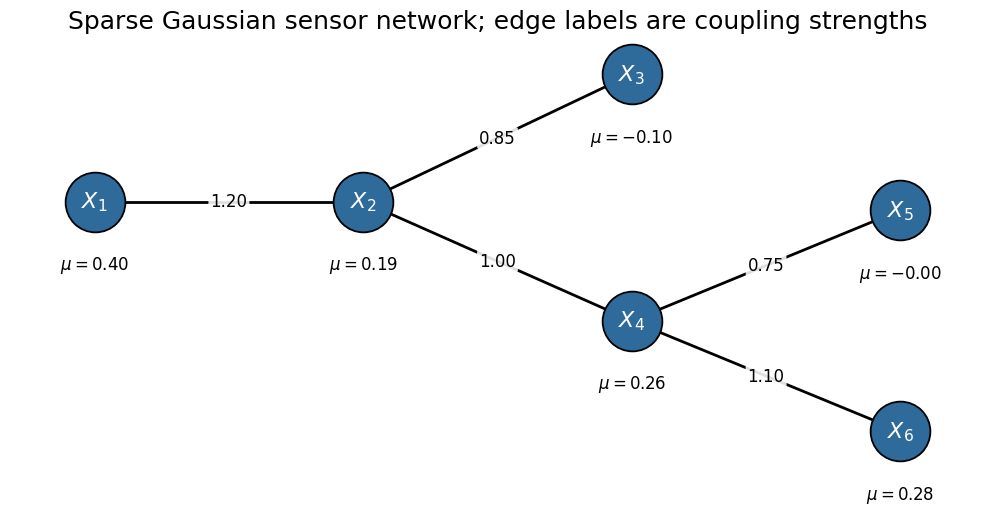

In [2]:
graph = nx.Graph()
graph.add_nodes_from(range(n))
graph.add_edges_from(edges)
pos = {0: (0, 0.7), 1: (1.4, 0.7), 2: (2.8, 1.45), 3: (2.8, 0), 4: (4.2, 0.65), 5: (4.2, -0.65)}
labels = {i: rf"$X_{{{i+1}}}$" for i in range(n)}

fig, ax = plt.subplots(figsize=(10.2, 5.4))
nx.draw_networkx_edges(graph, pos, width=2.0, ax=ax)
nx.draw_networkx_nodes(graph, pos, node_size=1850, node_color="#2F6B9A", edgecolors="black", linewidths=1.3, ax=ax)
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=16, font_color="white", ax=ax)
for i, (x, y) in pos.items():
    ax.text(x, y - 0.31, rf"$\mu={mu[i]:.2f}$", ha="center", va="top", fontsize=12,
            bbox={"boxstyle": "round,pad=0.10", "facecolor": "white", "edgecolor": "none", "alpha": 0.88})
edge_labels = {(i, j): f"{edge_weights[(i, j)]:.2f}" for i, j in edges}
nx.draw_networkx_edge_labels(
    graph, pos, edge_labels=edge_labels, font_size=12, rotate=False,
    bbox={"boxstyle": "round,pad=0.12", "facecolor": "white", "edgecolor": "none", "alpha": 0.88}, ax=ax
)
ax.set_title("Sparse Gaussian sensor network; edge labels are coupling strengths")
ax.axis("off")
fig.tight_layout()
save_figure(fig, "ch02_05_gaussian_network")
plt.show()

## 3. Sparse precision and dense covariance

The zero pattern of $J$ mirrors missing graph edges. The inverse matrix $\Sigma=J^{-1}$ is dense because marginal correlations propagate along graph paths.

Saved: figs/ch02_05_precision_and_covariance.pdf


Saved: figs/ch02_05_precision_and_covariance.png


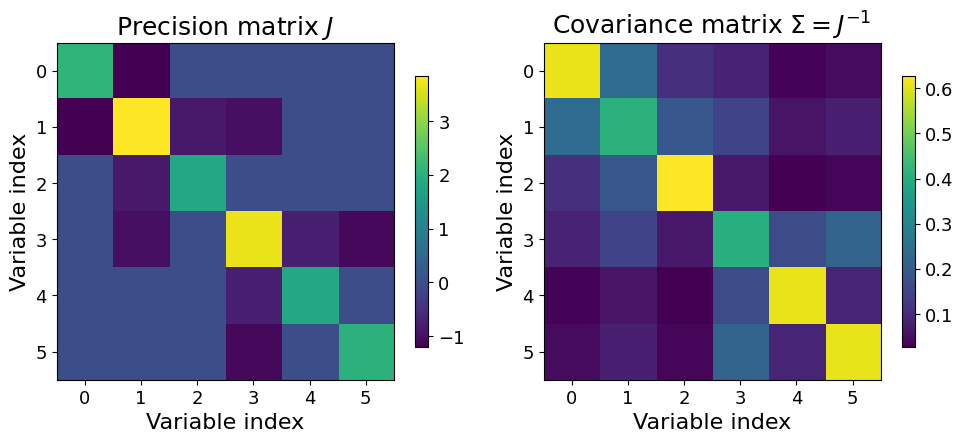

Number of nonzero off-diagonal entries in J: 10
Number of numerically nonzero off-diagonal entries in Sigma: 30


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
image0 = axes[0].imshow(J)
axes[0].set_title("Precision matrix $J$")
axes[0].set_xlabel("Variable index")
axes[0].set_ylabel("Variable index")
image1 = axes[1].imshow(Sigma)
axes[1].set_title(r"Covariance matrix $\Sigma=J^{-1}$")
axes[1].set_xlabel("Variable index")
axes[1].set_ylabel("Variable index")
fig.colorbar(image0, ax=axes[0], shrink=0.78)
fig.colorbar(image1, ax=axes[1], shrink=0.78)
fig.tight_layout()
save_figure(fig, "ch02_05_precision_and_covariance")
plt.show()

print("Number of nonzero off-diagonal entries in J:", np.count_nonzero(J - np.diag(np.diag(J))))
print("Number of numerically nonzero off-diagonal entries in Sigma:",
      np.count_nonzero(np.abs(Sigma - np.diag(np.diag(Sigma))) > 1e-12))

## 4. Exact marginal distributions

Every component is marginally Gaussian,

$$
X_i\sim\mathcal{N}(\mu_i,\Sigma_{ii}).
$$

The error bars below show one standard deviation around each exact mean.

,variable,mean,standard deviation
0,X1,0.397032,0.781837
1,X2,0.194806,0.643180
2,X3,-0.099684,0.792382
3,X4,0.258296,0.639506
4,X5,-0.003394,0.779587
5,X6,0.284939,0.778175


Saved: figs/ch02_05_gaussian_marginals.pdf


Saved: figs/ch02_05_gaussian_marginals.png


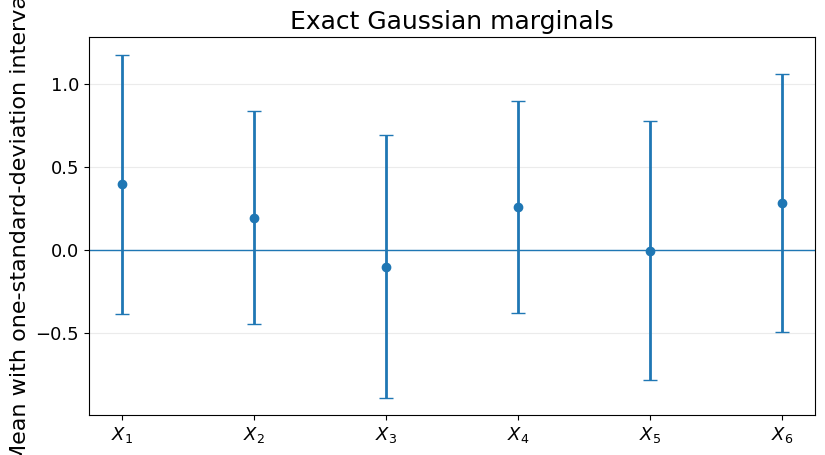

In [4]:
standard_deviation = np.sqrt(np.diag(Sigma))
summary = pd.DataFrame({
    "variable": [f"X{i+1}" for i in range(n)],
    "mean": mu,
    "standard deviation": standard_deviation,
})
display(summary)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
indices = np.arange(1, n + 1)
ax.errorbar(indices, mu, yerr=standard_deviation, fmt="o", capsize=5)
ax.axhline(0, linewidth=1)
ax.set_xticks(indices, [rf"$X_{i}$" for i in indices])
ax.set_ylabel("Mean with one-standard-deviation interval")
ax.set_title("Exact Gaussian marginals")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_05_gaussian_marginals")
plt.show()

## 5. Sampling and moment verification

Exact samples are generated by

$$
\boldsymbol{x}=\boldsymbol{\mu}+L\boldsymbol{\xi},
$$

where $LL^{T}=\Sigma$ and $\boldsymbol{\xi}\sim\mathcal{N}(\boldsymbol{0},I)$.

In [5]:
num_samples = 20000
samples = RNG.multivariate_normal(mu, Sigma, size=num_samples)
empirical_mu = samples.mean(axis=0)
empirical_Sigma = np.cov(samples, rowvar=False, ddof=0)

print("Maximum absolute mean error:", np.max(np.abs(empirical_mu - mu)))
print("Relative covariance error:", np.linalg.norm(empirical_Sigma - Sigma) / np.linalg.norm(Sigma))
assert np.max(np.abs(empirical_mu - mu)) < 0.04
assert np.linalg.norm(empirical_Sigma - Sigma) / np.linalg.norm(Sigma) < 0.05

Maximum absolute mean error: 0.011935787818858217
Relative covariance error: 0.010975439169907463


## 6. Conditional independence by residualization

Nodes $X_1$ and $X_3$ are connected only through $X_2$. They are correlated marginally. Once the linear dependence on $X_2$ is removed from both variables, the residuals are uncorrelated, which is equivalent to conditional independence for a Gaussian distribution.

corr(X1, X3) = 0.17468
corr(X1, X3 | X2), estimated from residuals = -0.00118


Saved: figs/ch02_05_conditional_independence.pdf


Saved: figs/ch02_05_conditional_independence.png


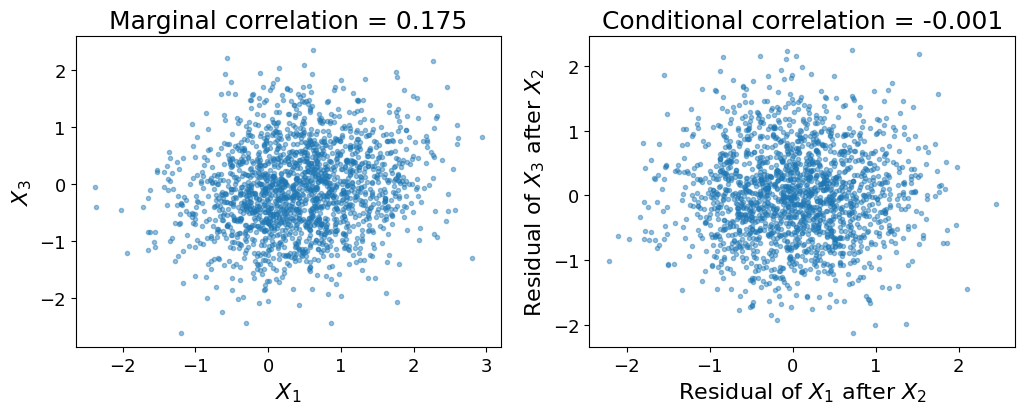

In [6]:
x1 = samples[:, 0]
x2 = samples[:, 1]
x3 = samples[:, 2]

A = np.column_stack([np.ones(num_samples), x2])
coef1, *_ = np.linalg.lstsq(A, x1, rcond=None)
coef3, *_ = np.linalg.lstsq(A, x3, rcond=None)
residual1 = x1 - A @ coef1
residual3 = x3 - A @ coef3

raw_corr = np.corrcoef(x1, x3)[0, 1]
residual_corr = np.corrcoef(residual1, residual3)[0, 1]
print(f"corr(X1, X3) = {raw_corr:.5f}")
print(f"corr(X1, X3 | X2), estimated from residuals = {residual_corr:.5f}")

selection = RNG.choice(num_samples, size=1800, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
axes[0].scatter(x1[selection], x3[selection], s=9, alpha=0.45)
axes[0].set_xlabel(r"$X_1$")
axes[0].set_ylabel(r"$X_3$")
axes[0].set_title(f"Marginal correlation = {raw_corr:.3f}")
axes[1].scatter(residual1[selection], residual3[selection], s=9, alpha=0.45)
axes[1].set_xlabel(r"Residual of $X_1$ after $X_2$")
axes[1].set_ylabel(r"Residual of $X_3$ after $X_2$")
axes[1].set_title(f"Conditional correlation = {residual_corr:.3f}")
fig.tight_layout()
save_figure(fig, "ch02_05_conditional_independence")
plt.show()

## 7. Monte Carlo convergence

Although exact moments are available here, many later models require empirical estimation. We measure the relative Frobenius error of the sample covariance as the sample size grows.

Saved: figs/ch02_05_covariance_convergence.pdf
Saved: figs/ch02_05_covariance_convergence.png


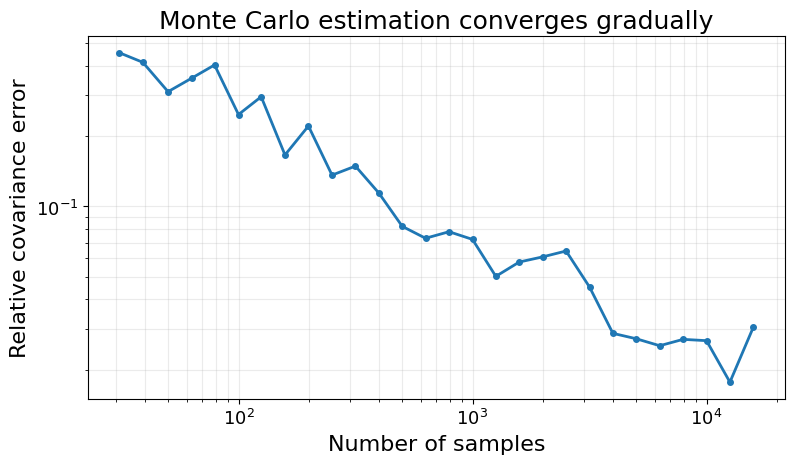

In [7]:
sample_sizes = np.unique(np.logspace(1.5, 4.2, 28).astype(int))
errors = []
for size in sample_sizes:
    sample = RNG.multivariate_normal(mu, Sigma, size=size)
    estimate = np.cov(sample, rowvar=False, ddof=0)
    errors.append(np.linalg.norm(estimate - Sigma) / np.linalg.norm(Sigma))

fig, ax = plt.subplots(figsize=(8.2, 4.9))
ax.loglog(sample_sizes, errors, marker="o", markersize=4)
ax.set_xlabel("Number of samples")
ax.set_ylabel("Relative covariance error")
ax.set_title("Monte Carlo estimation converges gradually")
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_05_covariance_convergence")
plt.show()

## 8. Interpretation

This example illustrates a central duality:

- the precision matrix is sparse and local;
- the covariance matrix is dense and global.

The graphical model stores local conditional dependence rather than every marginal correlation. This distinction is essential in spatial statistics, state estimation, inverse problems, energy systems, and Gaussian approximations to nonlinear models.

The model is also an energy-based model with a quadratic energy. Later, stochastic dynamics can be designed to sample this density, and diffusion models can be interpreted as learning time-dependent versions of related scores and drifts.

## 9. Exercises

### Exercise 1: Verify the partition function

Evaluate the density at selected points and numerically integrate a two-dimensional submodel. Compare with the analytic normalization formula.

### Exercise 2: Remove an edge

Set one coupling to zero. Compare the changed zero pattern of $J$ with the new covariance matrix.

### Exercise 3: Add an observation

Increase one diagonal precision and modify the corresponding entry of $\boldsymbol{h}$. Interpret the operation as adding a noisy local measurement.

### Exercise 4: Conditional distribution

Derive and compute the Gaussian conditional distribution of $X_1$ given $X_2=x_2$. Compare its mean with a linear regression fitted to samples.

### Exercise 5: Partial correlations

Compute the partial-correlation matrix directly from $J$ using

$$
\rho_{ij\mid -ij}
=
-\frac{J_{ij}}{\sqrt{J_{ii}J_{jj}}}.
$$

Verify that it has the same sparsity pattern as the graph.

### Exercise 6: Graph reconstruction

Estimate the covariance from samples, invert it with and without regularization, and test how accurately the graph edges can be recovered.

### Exercise 7: Gaussian belief-propagation preview

Choose the tree orientation rooted at $X_1$. Derive the elimination order and predict why local Gaussian messages are sufficient for exact inference.